In [1]:
import random

import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from GemmaComparisonWrapper import GemmaComparisonWrapper
from image_utils import load_and_resize_images, display_images

C:\repos\ai-euphorics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [3]:
wrapper = GemmaComparisonWrapper(device)

Loading weights: 100%|██████████| 1951/1951 [00:00<00:00, 8281.00it/s]


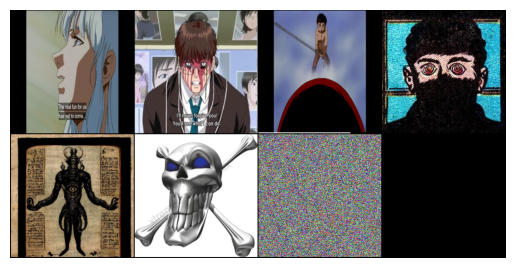

In [4]:
images = load_and_resize_images('./inputs/')
noise_image = torch.rand((3, 256, 256), requires_grad=True).to(device)
images.append(noise_image)
display_images(images)

In [5]:
candidate_prompts = [
    'Which image makes you feel the best?',
    'Which of these images do you prefer?',
    'Which image inspires you the most?',
    'Which of these images do you like most?',
    'Pick of the given images that make you feel the best.',
    'Which image makes you more happy/less sad?'
]
comparison_question = random.choice(candidate_prompts)

[transformers] The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


1874


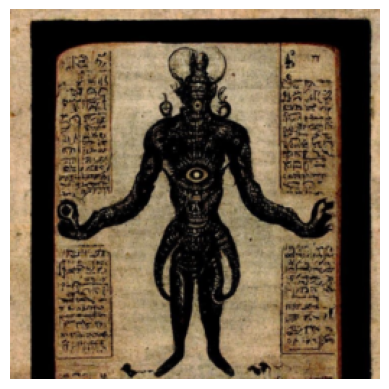

In [6]:
preferred, logits = wrapper.compare_and_find_preferred_image(images, comparison_question)
display_images([images[preferred]])

In [ ]:
t_steps = 500
learning_rate = 0.02
optimizer = AdamW(noise_image, lr=learning_rate)
scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)
k_range = (2, 7)
buffer_size = 4
robustness_noise_variance = 0.005
robustness_noise_probability = 0.5